<a href="https://colab.research.google.com/github/freddy-7/TI3002C/blob/main/6_Regresi%C3%B3n_Lineal__Simple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_leads = pd.read_csv('leads_reales_clean.csv')

**Proceso de limpieza**

In [4]:
df_leads.dtypes

Año                int64
Mes                  str
Total              int64
Ilocalizable       int64
No_Contesta        int64
D_Incorrectos      int64
Duplicados         int64
Efectivos          int64
Abiertos           int64
Ventas             int64
Conversion       float64
Efectividad        int64
dtype: object

In [5]:
df_leads.Mes.replace({'Enero': 1, 'Febrero': 2, 'Marzo': 3, 'Abril': 4, 'Mayo': 5, 'Junio': 6, 'Julio': 7, 'Agosto': 8, 'Septiembre': 9, 'Octubre': 10, 'Noviembre': 11, 'Diciembre': 12}, regex=False)

0      2
1      3
2      4
3      5
4      6
5      7
6      8
7      9
8     10
9     11
10    12
11     1
12     2
13     3
14     4
15     5
16     6
17     7
18     8
19     9
20    10
21    11
22    12
23     1
24     2
25     3
26     4
27     5
Name: Mes, dtype: object

In [6]:
df_leads['Mes'] = df_leads.Mes.replace({'Enero': 1, 'Febrero': 2, 'Marzo': 3, 'Abril': 4, 'Mayo': 5, 'Junio': 6, 'Julio': 7, 'Agosto': 8, 'Septiembre': 9, 'Octubre': 10, 'Noviembre': 11, 'Diciembre': 12}, regex=False)

In [7]:
df_leads.head()

,Año,Mes,Total,Ilocalizable,No_Contesta,D_Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad
0,2024,2,543,108,33,0,1,389,1,12,3.1,72
1,2024,3,178,37,13,0,0,128,1,7,5.5,72
2,2024,4,416,79,46,3,0,288,1,8,2.8,69
3,2024,5,422,33,100,17,0,274,5,13,4.7,65
4,2024,6,967,140,173,31,3,620,17,6,1.0,64


In [8]:
df_leads['Mes'] = pd.to_numeric(df_leads['Mes'], errors='coerce').astype('Int64')

In [9]:
df_leads.dtypes

Año                int64
Mes                Int64
Total              int64
Ilocalizable       int64
No_Contesta        int64
D_Incorrectos      int64
Duplicados         int64
Efectivos          int64
Abiertos           int64
Ventas             int64
Conversion       float64
Efectividad        int64
dtype: object

In [10]:
df_leads.isnull().sum()

Año              0
Mes              0
Total            0
Ilocalizable     0
No_Contesta      0
D_Incorrectos    0
Duplicados       0
Efectivos        0
Abiertos         0
Ventas           0
Conversion       0
Efectividad      0
dtype: int64

¿los leads efectivos están relacionados con las ventas?

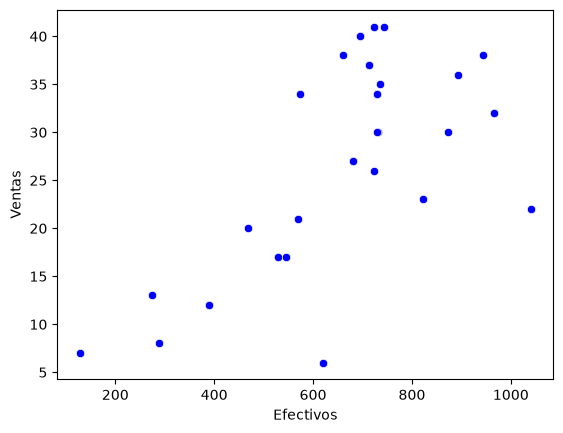

In [11]:
# Imprimimos el scatter plot entre la variable dependiente (Ventas) e independiente (Efectivos)
# para observar el comportamiento en su dispersión 
sns.scatterplot(x='Efectivos', y='Ventas', color="blue", data=df_leads)
plt.show()

Tendencia positiva: A medida que aumenta el número de leads Efectivos en el eje X, la variable Ventas en el eje Y tiende a incrementarse.

¿Cuando GAC genera un mayor volumen de leads, también aumenta la cantidad de prospectos que no logra localizar?

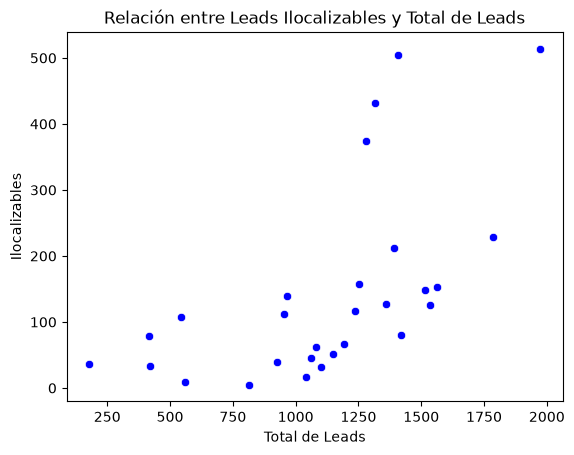

In [50]:
#Imprimimos el scatter plot entre la variable Total e Ilocalizable
#para observar el comportamiento en su dispersión

sns.scatterplot(x='Total', y='Ilocalizable', color="blue", data =df_leads)

plt.title('Relación entre Leads Ilocalizables y Total de Leads')
plt.xlabel('Total de Leads')
plt.ylabel('Ilocalizables')

plt.show()

In [51]:
# Declaramos las variables dependiente e independiente para la regresión lineal
Vars_Indep = df_leads[['Total']]
Var_Dep = df_leads['Ilocalizable']

In [14]:
#Se define model como la función de regresión lineal

from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [52]:
#Ajustamos el modelo con las variables antes declaradas

model.fit(X=Vars_Indep, y=Var_Dep)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.2]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Total']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-81.73
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [53]:
#Verificamos los coeficientes obtenidos
#para el modelo ajustado

model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['Total'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.20029829]),
 'rank_': np.int64(1),
 'singular_': array([2192.46423655]),
 'intercept_': np.float64(-81.72778918730381)}

In [54]:
print("Intercepto:", model.intercept_)
print("Coeficiente:", model.coef_[0])

Intercepto: -81.72778918730381
Coeficiente: 0.20029828553576673


Ilocalizables = 0.2003(Total de Leads) - 81.72
R^2 = 0.42

In [55]:
#Evaluamos la eficiencia del modelo obtenido
#por medio del coeficiente R de Determinación

model.score(Vars_Indep, Var_Dep)

0.3458731920855531

In [56]:
#Predecimos los valores del Total de Leads
#a partir de la variable Ilocalizable

y_pred = model.predict(X=df_leads[['Total']])

y_pred

array([ 27.03417986, -46.07469436,   1.5962976 ,   2.79808731,
       111.96065293, 109.35677521, 200.49249513, 181.66445629,
       313.46072817, 231.13813282, 175.05461287, 126.98302434,
        30.639549  , 103.54812493, 148.41494089,  81.51531352,
       135.19525405, 190.27728257, 202.49547799, 138.6003249 ,
       157.02776717, 130.78869177, 225.52978082, 221.92441168,
       165.64059345, 275.80465049, 197.28772256, 168.84536602])

In [58]:
#Insertamos la columna de predicciones en el DataFrame

df_leads['Predicciones'] = y_pred

df_leads

,Predicciones,Año,Mes,Total,Ilocalizable,No_Contesta,D_Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad
0,27.034180,2024,2,543,108,33,0,1,389,1,12,3.1,72
1,-46.074694,2024,3,178,37,13,0,0,128,1,7,5.5,72
2,1.596298,2024,4,416,79,46,3,0,288,1,8,2.8,69
3,2.798087,2024,5,422,33,100,17,0,274,5,13,4.7,65
4,111.960653,2024,6,967,140,173,31,3,620,17,6,1.0,64
5,109.356775,2024,7,954,112,251,12,9,570,5,21,3.7,60
6,200.492495,2024,8,1409,504,324,17,18,546,22,17,3.1,39
7,181.664456,2024,9,1315,431,314,14,26,530,42,17,3.2,40
8,313.460728,2024,10,1973,514,606,18,13,822,72,23,2.8,42
9,231.138133,2024,11,1562,153,321,44,4,1040,79,22,2.1,67


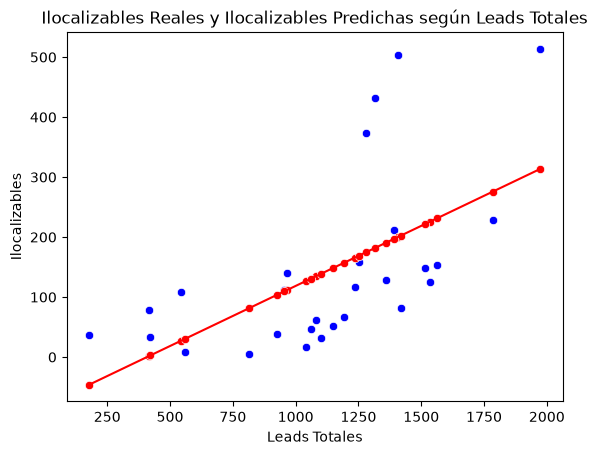

In [59]:
#Visualizamos la gráfica comparativa entre
#el Total real y el Total predicho

sns.scatterplot(x='Total', y='Ilocalizable', color="blue", data=df_leads)

sns.scatterplot(x='Total', y='Predicciones', color="red", data=df_leads)

sns.lineplot(x='Total', y='Predicciones', color="red", data=df_leads)

plt.title('Ilocalizables Reales y Ilocalizables Predichas según Leads Totales')
plt.xlabel('Leads Totales')
plt.ylabel('Ilocalizables')

plt.show()

In [60]:
#Corroboramos cuál es el coeficiente
#de Determinación de nuestro modelo

coef_Deter = model.score(X=Vars_Indep, y=Var_Dep)

coef_Deter

0.3458731920855531

In [61]:
#Corroboramos cuál es el coeficiente de Correlación de nuestro modelo

coef_Correl = np.sqrt(coef_Deter)

coef_Correl

np.float64(0.5881098469551017)

In [63]:
#Seleccionamos las variables relacionadas con los tipos de Leads

df_tipos_leads = df_leads[['Total', 'Ilocalizable', 'No_Contesta', 'D_Incorrectos','Duplicados', 'Efectivos', 'Abiertos', 
'Conversion', 'Efectividad', 'Ventas']]

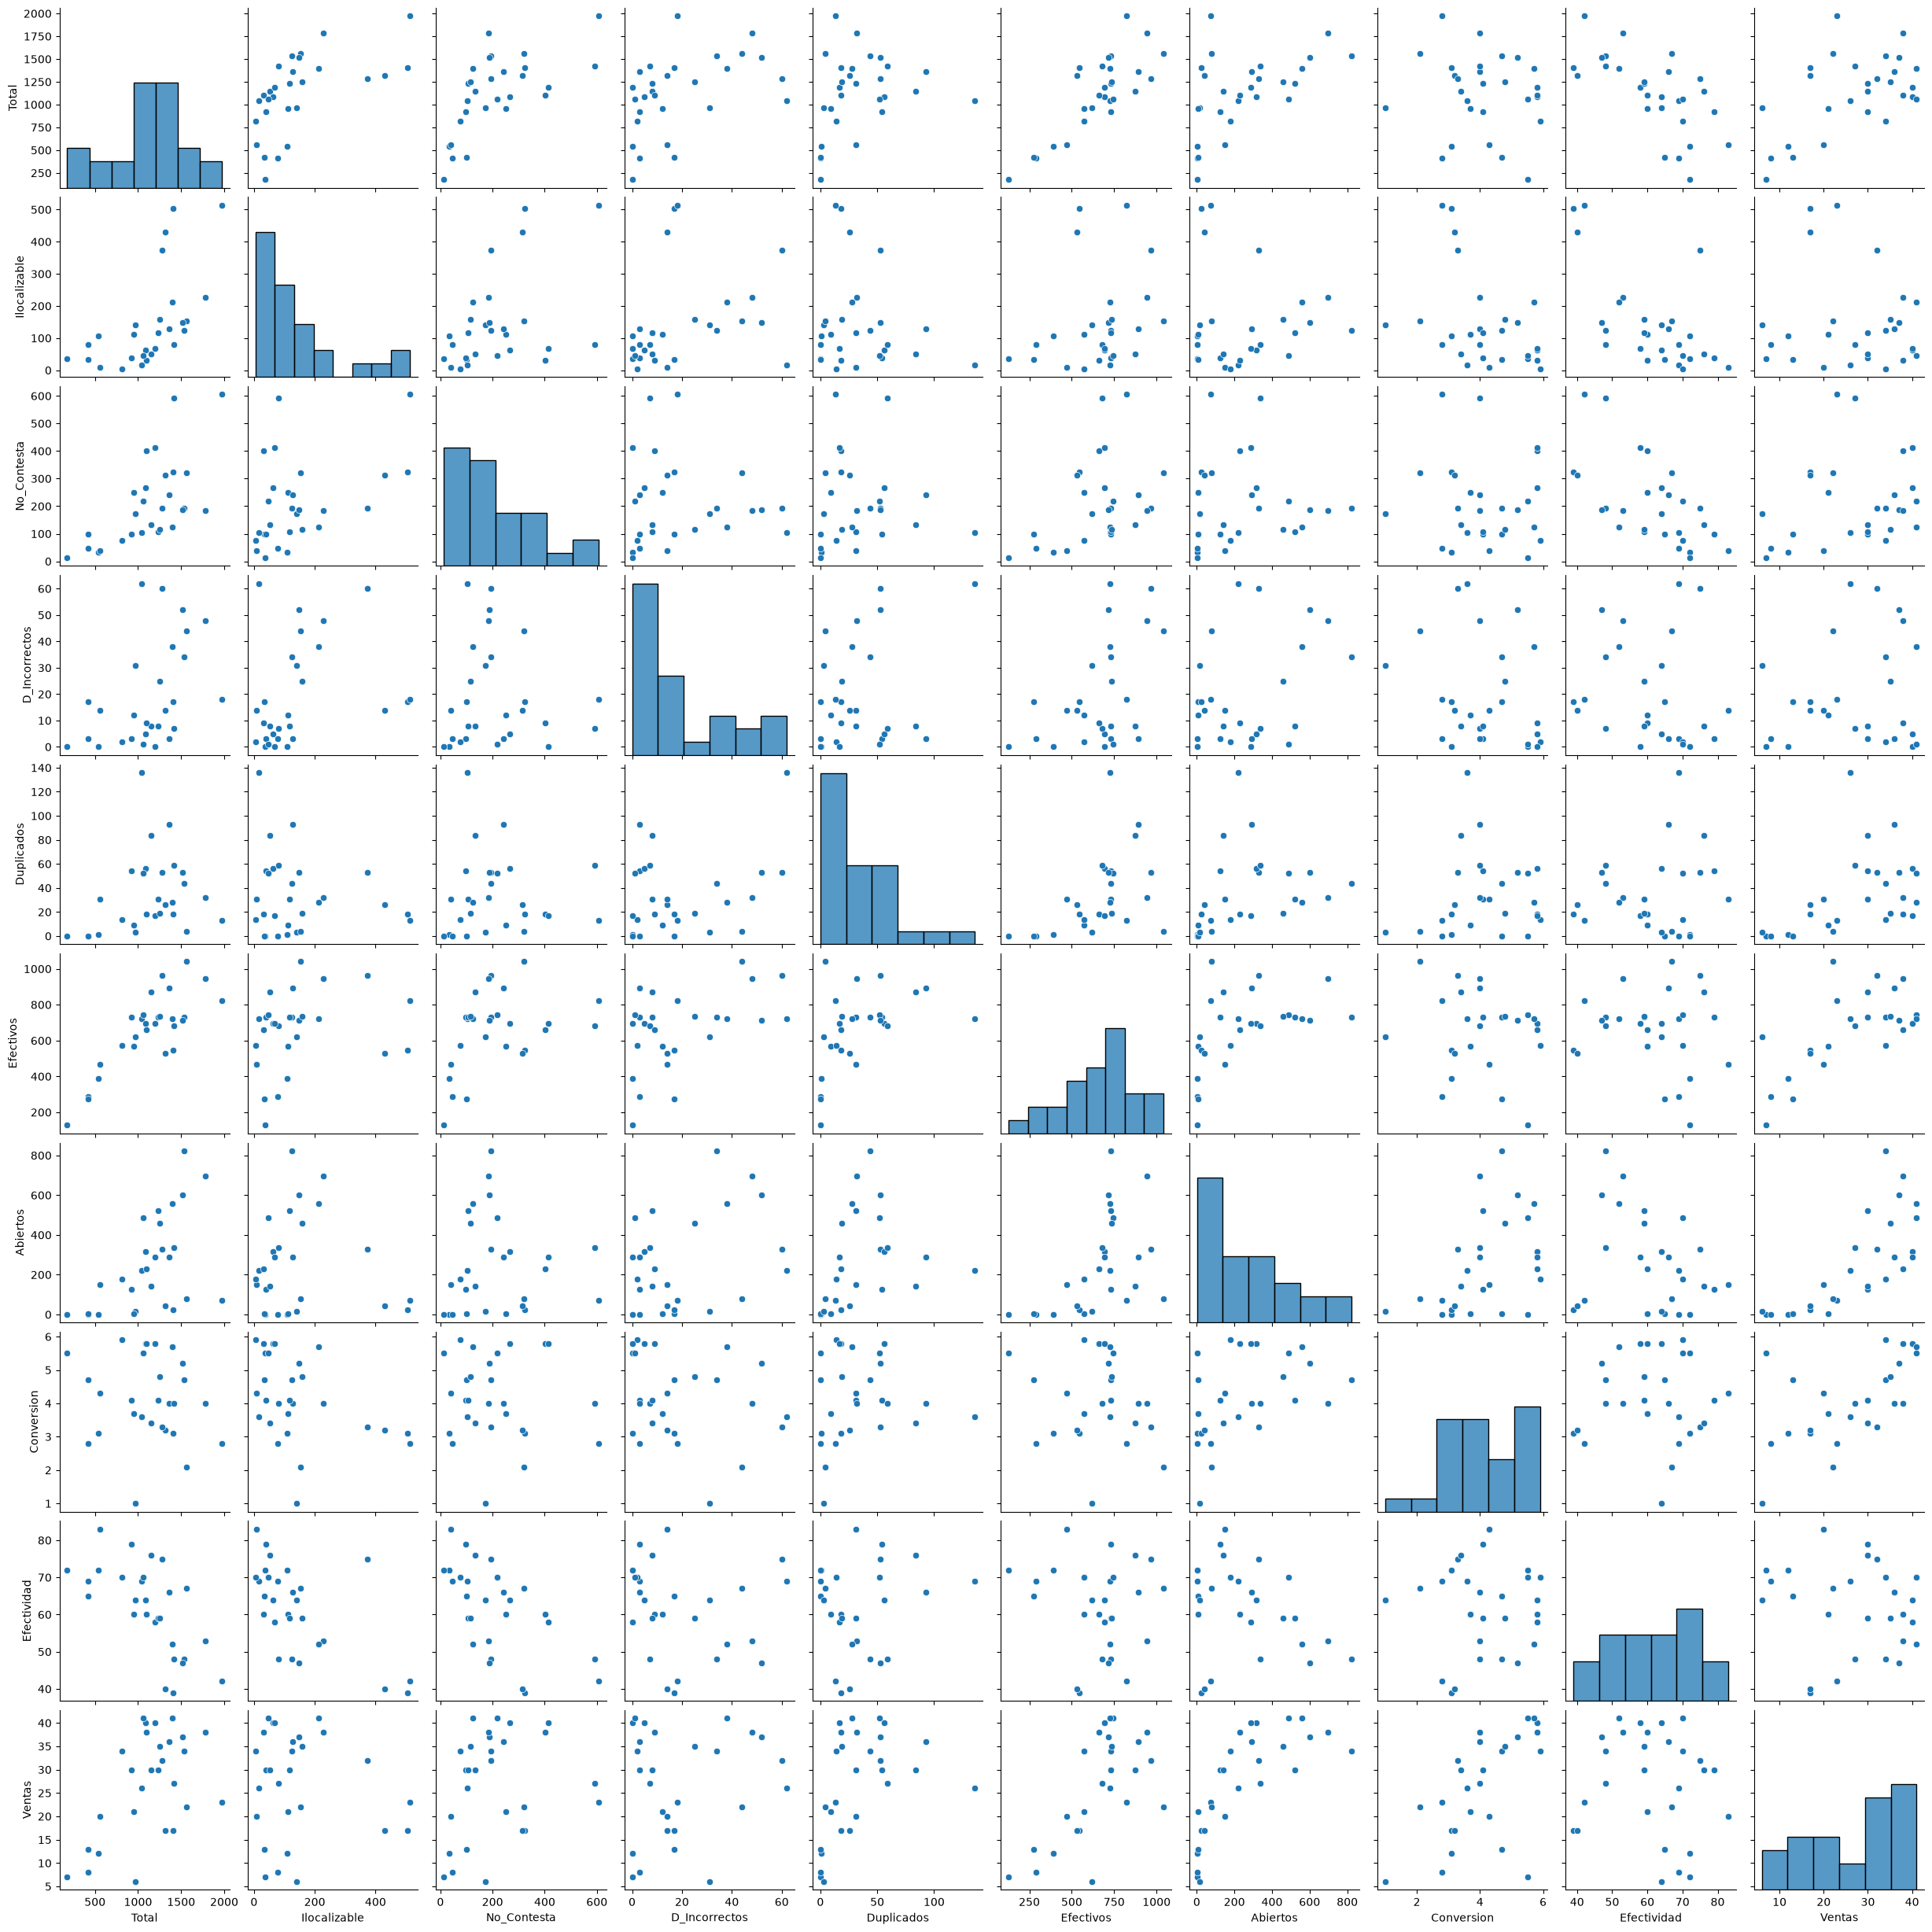

In [64]:
#Graficamos todas las dispersiones
#entre todas las variables

sns.pairplot(df_tipos_leads)

plt.show()

In [65]:
#Encontramos todas las correlaciones
#entre las variables

Corr_Factors = df_tipos_leads.corr()

Corr_Factors

,Total,Ilocalizable,No_Contesta,D_Incorrectos,Duplicados,Efectivos,Abiertos,Conversion,Efectividad,Ventas
Total,1.000000,0.588110,0.644815,0.453006,0.260949,0.812001,0.528382,-0.133595,-0.653776,0.534564
Ilocalizable,0.588110,1.000000,0.443577,0.293649,-0.162391,0.245740,-0.047827,-0.413785,-0.645820,-0.106959
No_Contesta,0.644815,0.443577,1.000000,-0.040028,0.012199,0.383725,0.013522,-0.088043,-0.611360,0.219976
D_Incorrectos,0.453006,0.293649,-0.040028,1.000000,0.287165,0.468292,0.382420,-0.247300,-0.177488,0.143903
Duplicados,0.260949,-0.162391,0.012199,0.287165,1.000000,0.467451,0.336402,0.085728,0.139829,0.451099
Efectivos,0.812001,0.245740,0.383725,0.468292,0.467451,1.000000,0.495192,-0.137212,-0.115353,0.654887
Abiertos,0.528382,-0.047827,0.013522,0.382420,0.336402,0.495192,1.000000,0.445734,-0.281941,0.752551
Conversion,-0.133595,-0.413785,-0.088043,-0.247300,0.085728,-0.137212,0.445734,1.000000,0.021724,0.626595
Efectividad,-0.653776,-0.645820,-0.611360,-0.177488,0.139829,-0.115353,-0.281941,0.021724,1.000000,-0.115155
Ventas,0.534564,-0.106959,0.219976,0.143903,0.451099,0.654887,0.752551,0.626595,-0.115155,1.000000


In [67]:
#Encontramos el valor absoluto de todas
#las correlaciones entre las variables

Corr_Factors1 = abs(Corr_Factors)

Corr_Factors1

,Total,Ilocalizable,No_Contesta,D_Incorrectos,Duplicados,Efectivos,Abiertos,Conversion,Efectividad,Ventas
Total,1.000000,0.588110,0.644815,0.453006,0.260949,0.812001,0.528382,0.133595,0.653776,0.534564
Ilocalizable,0.588110,1.000000,0.443577,0.293649,0.162391,0.245740,0.047827,0.413785,0.645820,0.106959
No_Contesta,0.644815,0.443577,1.000000,0.040028,0.012199,0.383725,0.013522,0.088043,0.611360,0.219976
D_Incorrectos,0.453006,0.293649,0.040028,1.000000,0.287165,0.468292,0.382420,0.247300,0.177488,0.143903
Duplicados,0.260949,0.162391,0.012199,0.287165,1.000000,0.467451,0.336402,0.085728,0.139829,0.451099
Efectivos,0.812001,0.245740,0.383725,0.468292,0.467451,1.000000,0.495192,0.137212,0.115353,0.654887
Abiertos,0.528382,0.047827,0.013522,0.382420,0.336402,0.495192,1.000000,0.445734,0.281941,0.752551
Conversion,0.133595,0.413785,0.088043,0.247300,0.085728,0.137212,0.445734,1.000000,0.021724,0.626595
Efectividad,0.653776,0.645820,0.611360,0.177488,0.139829,0.115353,0.281941,0.021724,1.000000,0.115155
Ventas,0.534564,0.106959,0.219976,0.143903,0.451099,0.654887,0.752551,0.626595,0.115155,1.000000


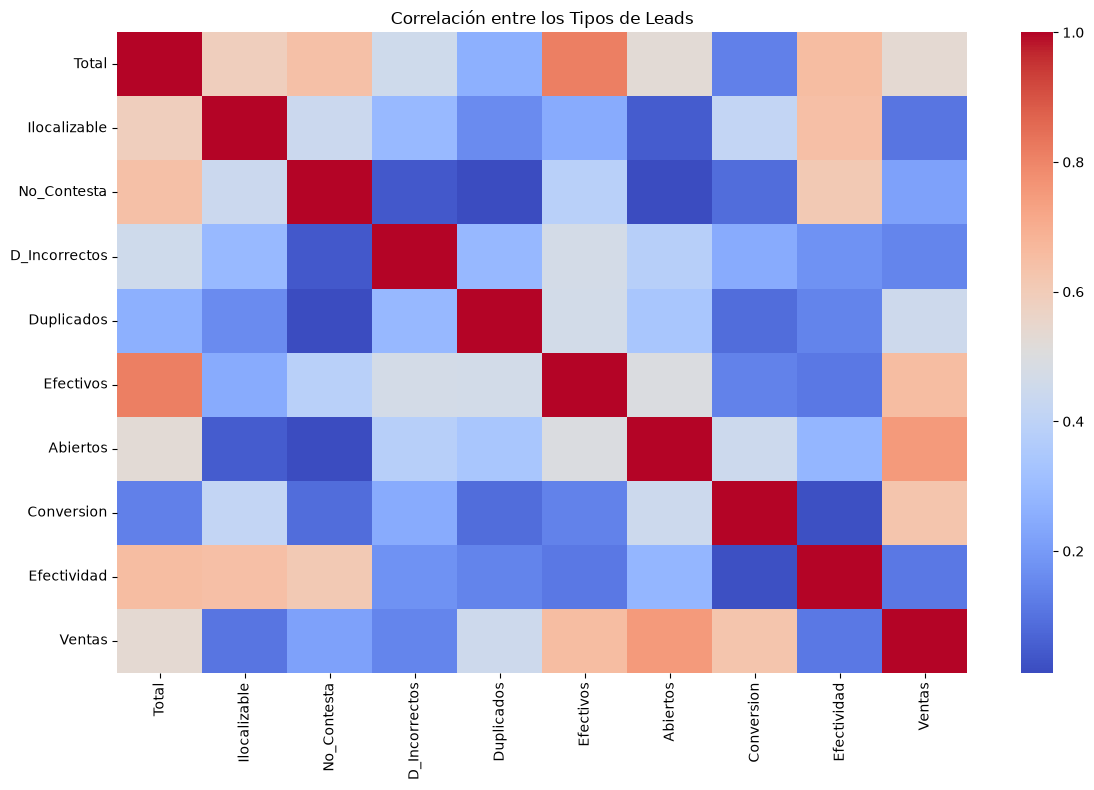

In [68]:
#Graficamos el mapa de calor
#de los coeficientes de correlación

plt.figure(figsize=(12, 8))

Heat_Map = sns.heatmap(Corr_Factors1, cmap='coolwarm')

Heat_Map

plt.title('Correlación entre los Tipos de Leads')
plt.tight_layout()
plt.show()

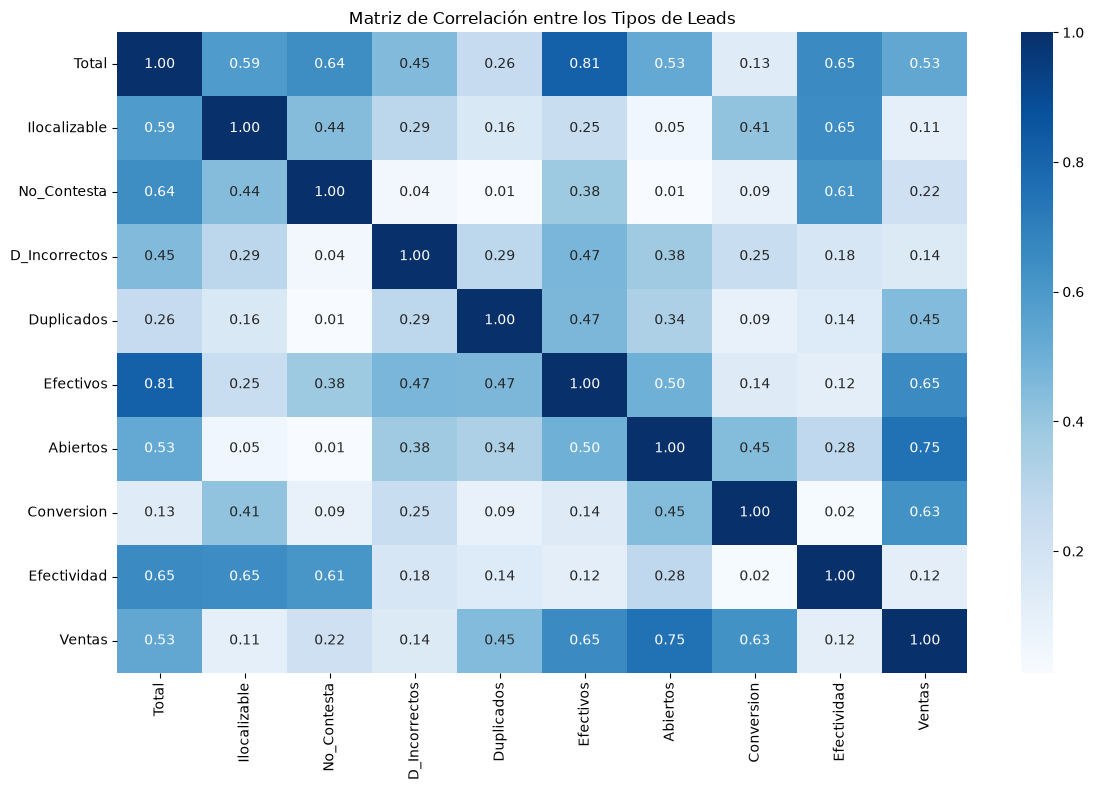

In [69]:
#Ajustamos el mapa de calor
#de los coeficientes de correlación

plt.figure(figsize=(12, 8))

Heat_Map = sns.heatmap(Corr_Factors1, cmap='Blues', annot=True, fmt=".2f")

Heat_Map
plt.title('Matriz de Correlación entre los Tipos de Leads')
plt.tight_layout()
plt.show()

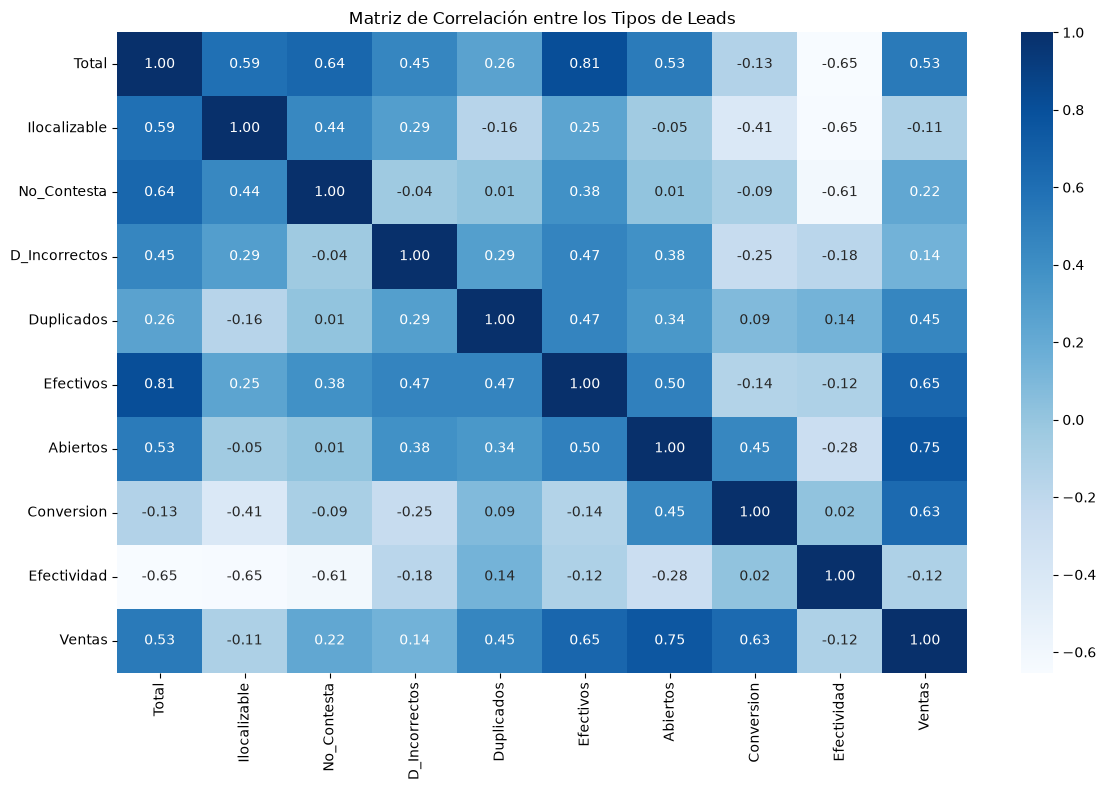

In [70]:
#Ajustamos el mapa de calor
#de los coeficientes de correlación

plt.figure(figsize=(12, 8))

Heat_Map = sns.heatmap(Corr_Factors, cmap='Blues', annot=True, fmt=".2f")

Heat_Map
plt.title('Matriz de Correlación entre los Tipos de Leads')
plt.tight_layout()
plt.show()

In [29]:
#Cargar archivo csv desde seaborn
df=sns.load_dataset(name='car_crashes')
df.head(5)

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA


In [30]:
#En caso de no poder cargar el archivo con seaborns leerlo con pandas
#df= pd.read_csv("car_crashes.csv")


<Axes: xlabel='alcohol', ylabel='total'>

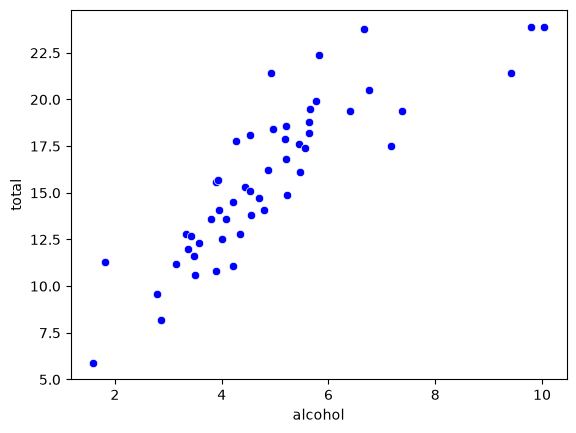

In [31]:
#Imprimimos el scatter plot entre la variable dependiente (total) e independiente (alcohol) 
#para observar el comportamiento en su dispersión 
from turtle import color
sns.scatterplot(x='alcohol', y='total', color="blue", data=df)
#sns.scatterplot(x='speeding', y='total', color="red", data=df)

In [32]:
#Declaramos las variables dependientes e independientes para la regresión lineal
#Vars_Indep= df[['alcohol', 'speeding']] #usamos dos corchetes para cuando son mas de dos variable y no marque error 
Vars_Indep= df[['alcohol']]
Var_Dep= df['total']

In [33]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [34]:
#Se define model como la función de regresión lineal
from sklearn.linear_model import LinearRegression
model= LinearRegression()

In [35]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[2.03]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['alcohol']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.858
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [36]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['alcohol'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([2.0325063]),
 'rank_': np.int64(1),
 'singular_': array([12.22681605]),
 'intercept_': np.float64(5.857776154826299)}

**Modelo matemático: y= 2.0325063(5.640) + 5.857776154826299**

---




In [37]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.7269492966665405

In [38]:
#Predecimos los valores de total de accidentes a partir de la variable "alcohol"
#y_pred= model.predict(X=df[['alcohol', 'speeding']])
y_pred= model.predict(X=df[['alcohol']])
y_pred

array([17.32111171, 15.05486718, 16.44306899, 17.69509287, 12.68699734,
       13.59756016, 13.76016066, 15.73575679,  9.0955587 , 16.40851638,
       13.78455074, 20.44100889, 14.87600663, 14.70324359, 14.40446516,
       13.8353634 , 14.54064309, 15.86177218, 19.6076813 , 15.06502971,
       13.98780137, 11.69106925, 13.88211104, 11.5162737 , 16.94713055,
       16.98371566, 24.99585551, 16.45729653, 15.41868581, 12.93089809,
       12.23171592, 15.95526747, 13.10772614, 16.44306899, 26.26007443,
       15.60161138, 17.58737003, 12.62195713, 17.32517672, 14.43088774,
       25.77430543, 18.86988151, 17.3515993 , 20.84141263,  9.53254755,
       14.15040187, 12.82724027, 12.96748321, 19.40239816, 15.11380986,
       17.17477126])

In [39]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(0, 'Predicciones', y_pred)
df

,Predicciones,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,17.321112,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,15.054867,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,16.443069,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,17.695093,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.686997,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA
5,13.597560,13.6,5.032,3.808,10.744,12.920,835.50,139.91,CO
6,13.760161,10.8,4.968,3.888,9.396,8.856,1068.73,167.02,CT
7,15.735757,16.2,6.156,4.860,14.094,16.038,1137.87,151.48,DE
8,9.095559,5.9,2.006,1.593,5.900,5.900,1273.89,136.05,DC
9,16.408516,17.9,3.759,5.191,16.468,16.826,1160.13,144.18,FL


<Axes: xlabel='alcohol', ylabel='total'>

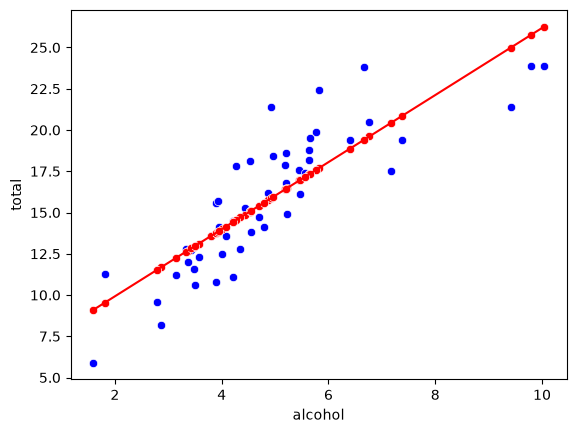

In [40]:
#Visualizamos la gráfica comparativa entre el total real y el total predecido

sns.scatterplot(x='alcohol', y='total', color="blue", data=df)
sns.scatterplot(x='alcohol', y='Predicciones', color="red", data=df)
sns.lineplot(x='alcohol', y='Predicciones', color="red", data=df)

In [41]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
coef_Deter

0.7269492966665405

In [42]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
coef_Correl

np.float64(0.8526132163334911)

In [43]:
#Eliminamos la columna tipo string
df= df.drop(['abbrev'], axis=1)

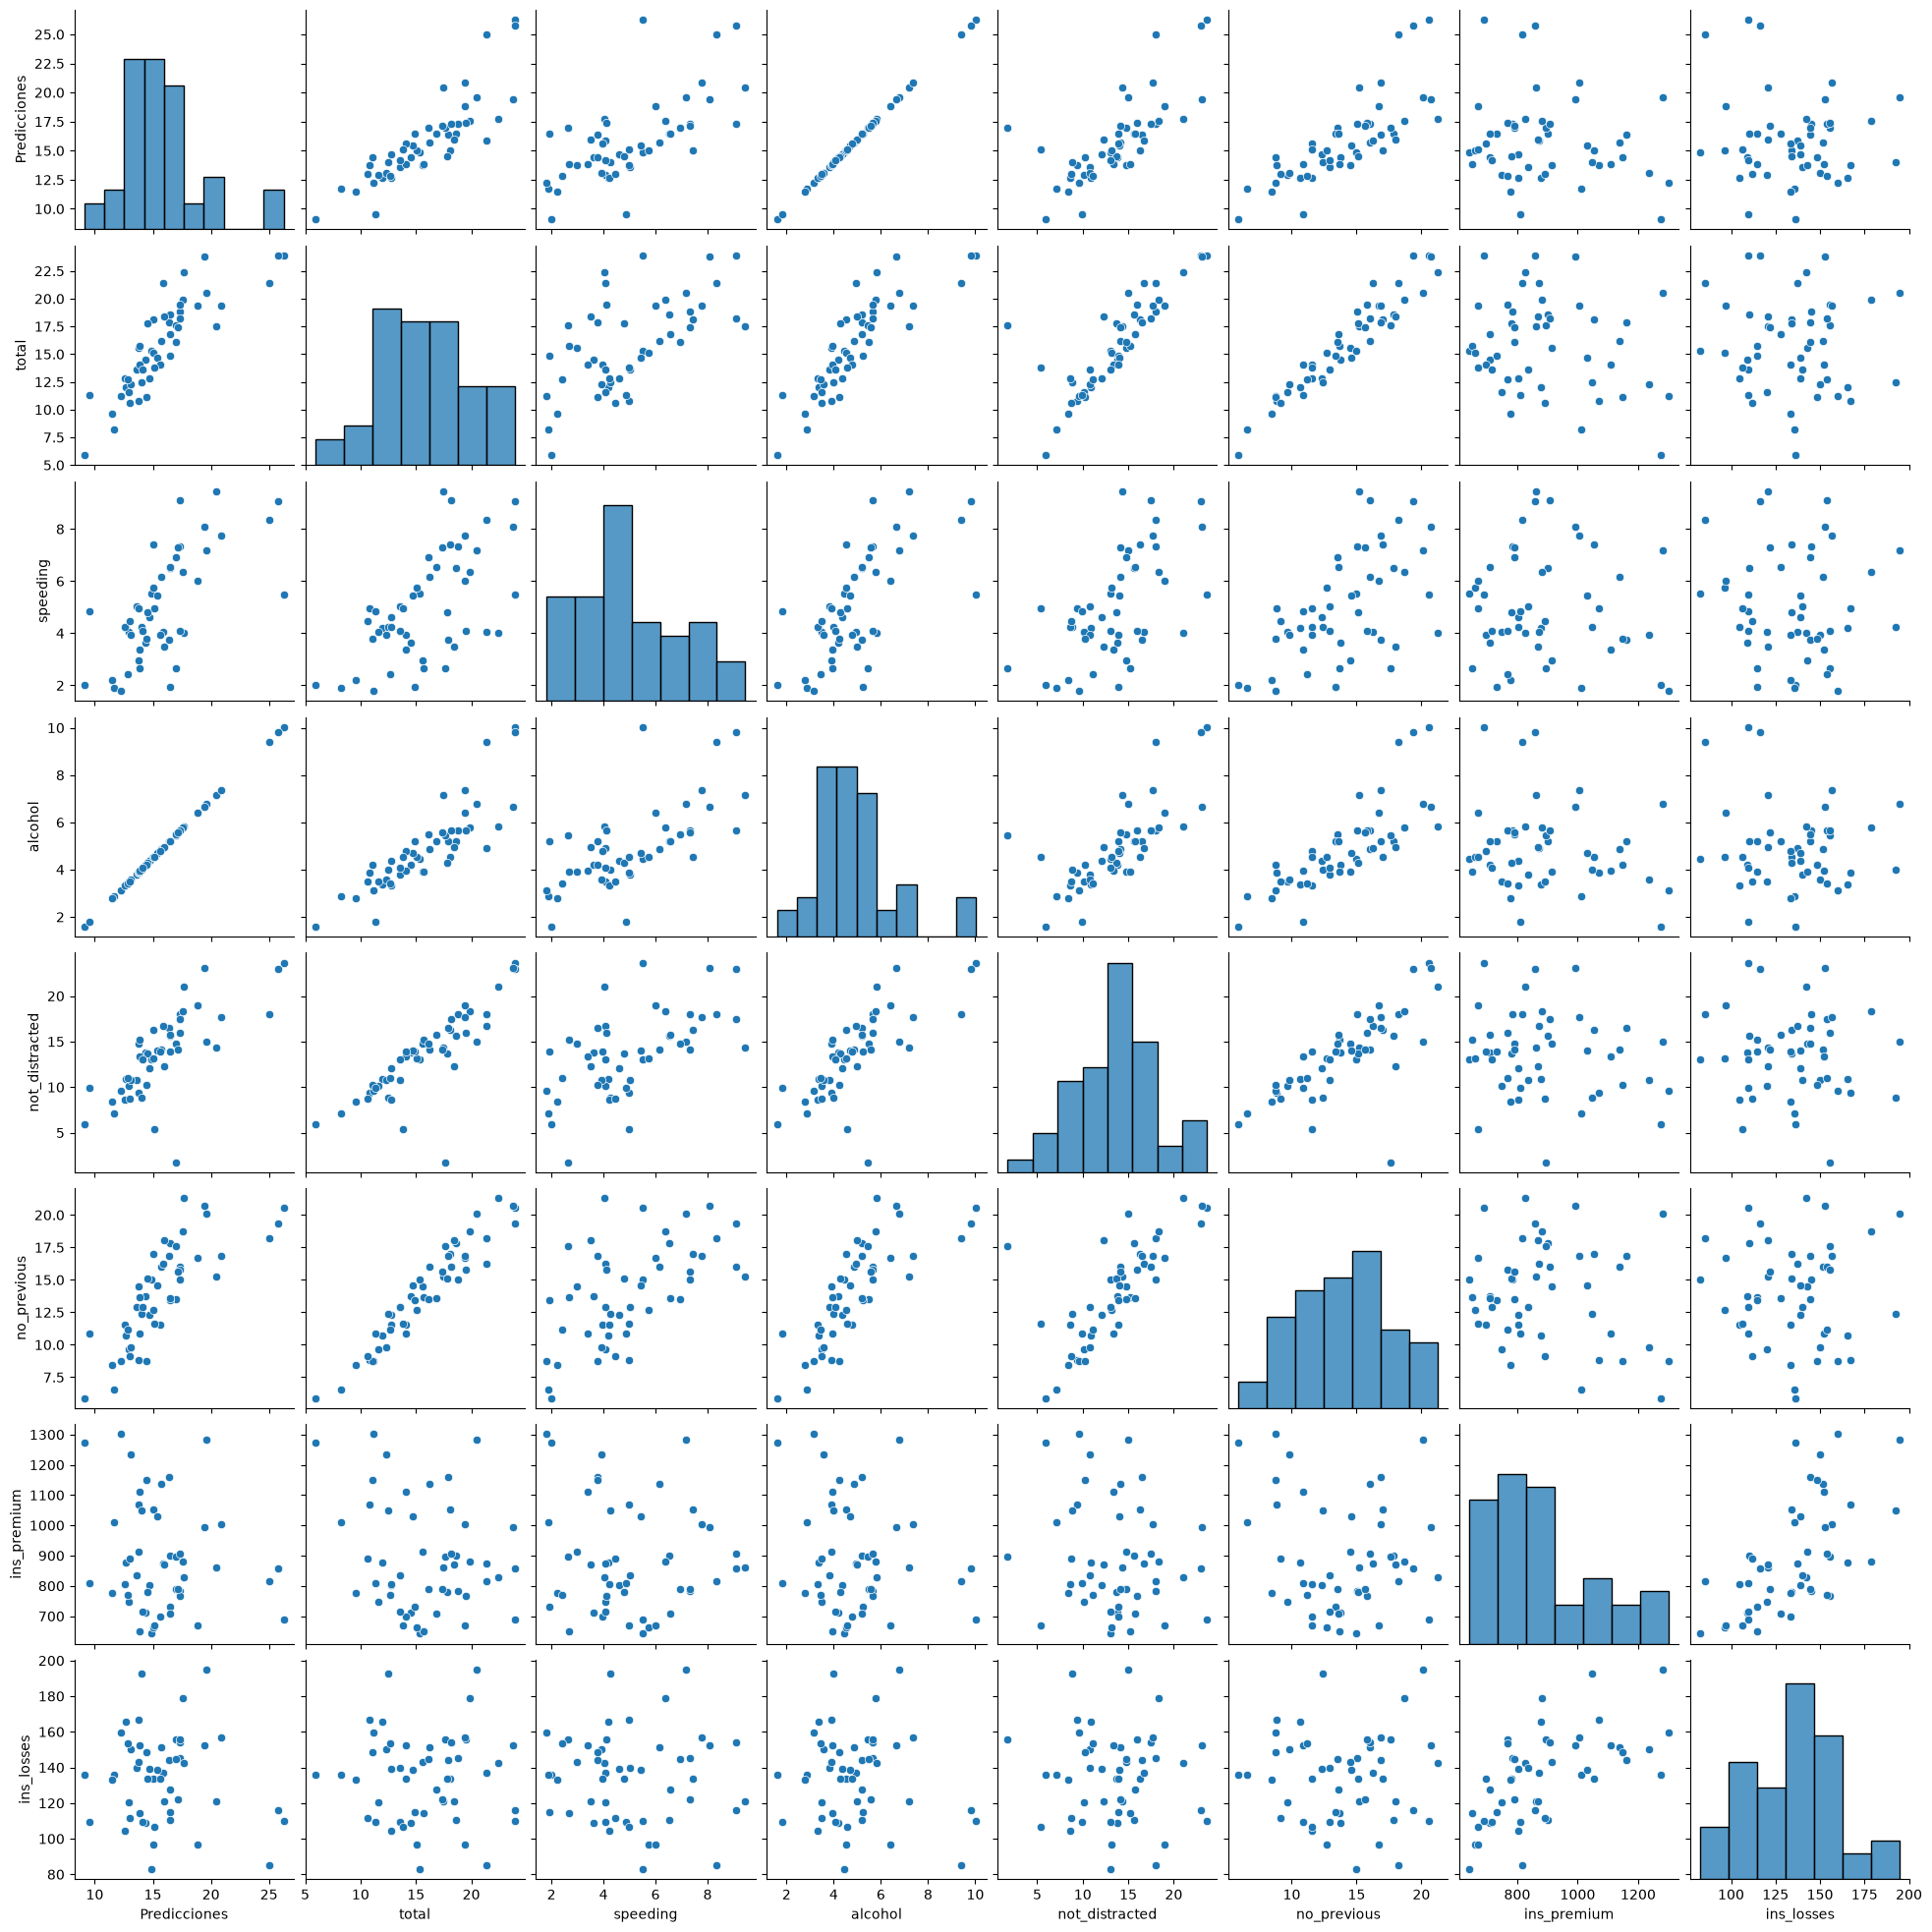

In [44]:
#Graficamos todas las dispersiones entre todas las variables
sns.pairplot(df)

In [45]:
#Encontramos todas las correlaciones entre las variables 
Corr_Factors=df.corr()
Corr_Factors

,Predicciones,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses
Predicciones,1.000000,0.852613,0.669719,1.000000,0.732816,0.783520,-0.170612,-0.112547
total,0.852613,1.000000,0.611548,0.852613,0.827560,0.956179,-0.199702,-0.036011
speeding,0.669719,0.611548,1.000000,0.669719,0.588010,0.571976,-0.077675,-0.065928
alcohol,1.000000,0.852613,0.669719,1.000000,0.732816,0.783520,-0.170612,-0.112547
not_distracted,0.732816,0.827560,0.588010,0.732816,1.000000,0.747307,-0.174856,-0.075970
no_previous,0.783520,0.956179,0.571976,0.783520,0.747307,1.000000,-0.156895,-0.006359
ins_premium,-0.170612,-0.199702,-0.077675,-0.170612,-0.174856,-0.156895,1.000000,0.623116
ins_losses,-0.112547,-0.036011,-0.065928,-0.112547,-0.075970,-0.006359,0.623116,1.000000


In [46]:
#Encontramos el valor absoluto de todas las correlaciones entre las variables 
Corr_Factors1= abs(Corr_Factors)
Corr_Factors1

,Predicciones,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses
Predicciones,1.000000,0.852613,0.669719,1.000000,0.732816,0.783520,0.170612,0.112547
total,0.852613,1.000000,0.611548,0.852613,0.827560,0.956179,0.199702,0.036011
speeding,0.669719,0.611548,1.000000,0.669719,0.588010,0.571976,0.077675,0.065928
alcohol,1.000000,0.852613,0.669719,1.000000,0.732816,0.783520,0.170612,0.112547
not_distracted,0.732816,0.827560,0.588010,0.732816,1.000000,0.747307,0.174856,0.075970
no_previous,0.783520,0.956179,0.571976,0.783520,0.747307,1.000000,0.156895,0.006359
ins_premium,0.170612,0.199702,0.077675,0.170612,0.174856,0.156895,1.000000,0.623116
ins_losses,0.112547,0.036011,0.065928,0.112547,0.075970,0.006359,0.623116,1.000000


<Axes: >

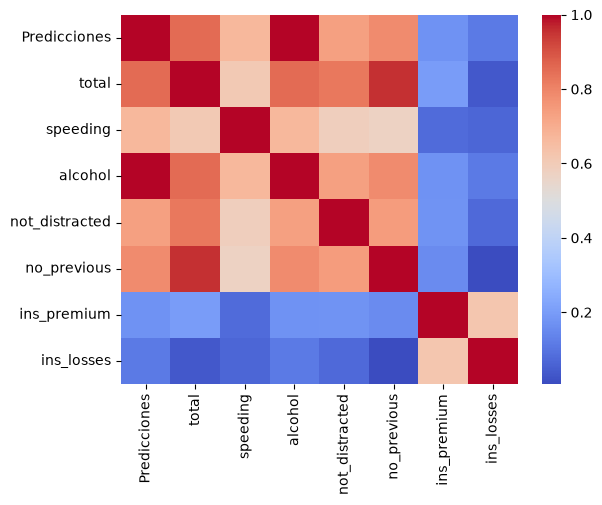

In [47]:
#Graficamos el mapa de calor de los coeficientes de correlación 
Heat_Map= sns.heatmap(Corr_Factors1, cmap = 'coolwarm')  
Heat_Map

<Axes: >

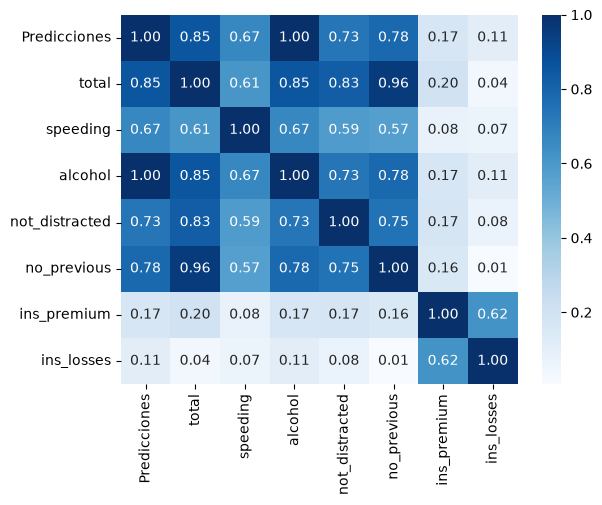

In [48]:
#Ajustamos el mapa de calor de los coeficientes de correlación 
Heat_Map= sns.heatmap(Corr_Factors1, cmap = 'Blues', annot=True, fmt=".2f")  
Heat_Map